# Two-Layer Transformers: Figures 11 And 12

This notebook was added because the report appendix includes two-layer experiments that were not present in `analysis/`. The corresponding W&B tags are `2-layer` for the minimal model and `2-layer-full` for the full model.


In [1]:
from analysis.utils import fetch_runs, fetch_run_data, plot_kl_divergence_simple, plot_val_loss_simple
import pandas as pd


SAVE_FIGURES = False


def output_path(name):
    return f"analysis/figures/{name}" if SAVE_FIGURES else None


## W&B Tag Inventory

The original plotting notebook used `u5m1g032` for the minimal model and `h22em72r` for the full model. The tag inventory is shown to make that selection auditable.


In [2]:
MINIMAL_TAG = "2-layer"
FULL_TAG = "2-layer-full"
TWO_LAYER_MINIMAL = "u5m1g032"
TWO_LAYER_FULL = "h22em72r"

rows = []
for tag in [MINIMAL_TAG, FULL_TAG]:
    for run in fetch_runs(tags_any=[tag]):
        rows.append({"tag": tag, "run_id": run.id, "name": run.name, "state": run.state})
pd.DataFrame(rows)


,tag,run_id,name,state
0,2-layer,zgzzw0ad,drawn-gorge-1765,crashed
1,2-layer,u5m1g032,dutiful-cosmos-1769,crashed
2,2-layer-full,e945cq5k,celestial-pond-1801,crashed
3,2-layer-full,h22em72r,stoic-star-1800,crashed
4,2-layer-full,7yzpjz6q,legendary-glitter-1808,crashed
5,2-layer-full,afud4alq,laced-spaceship-1809,crashed
6,2-layer-full,tu1k1tkh,feasible-terrain-1809,crashed
7,2-layer-full,wfmby0sq,stellar-wood-1809,crashed
8,2-layer-full,1mi17zxt,revived-leaf-1812,crashed
9,2-layer-full,iuanxca0,smart-hill-1813,crashed


## Figure 11: Two-Layer Minimal Transformer

The minimal two-layer model preserves the staged KL and loss transitions seen in the one-layer setting.


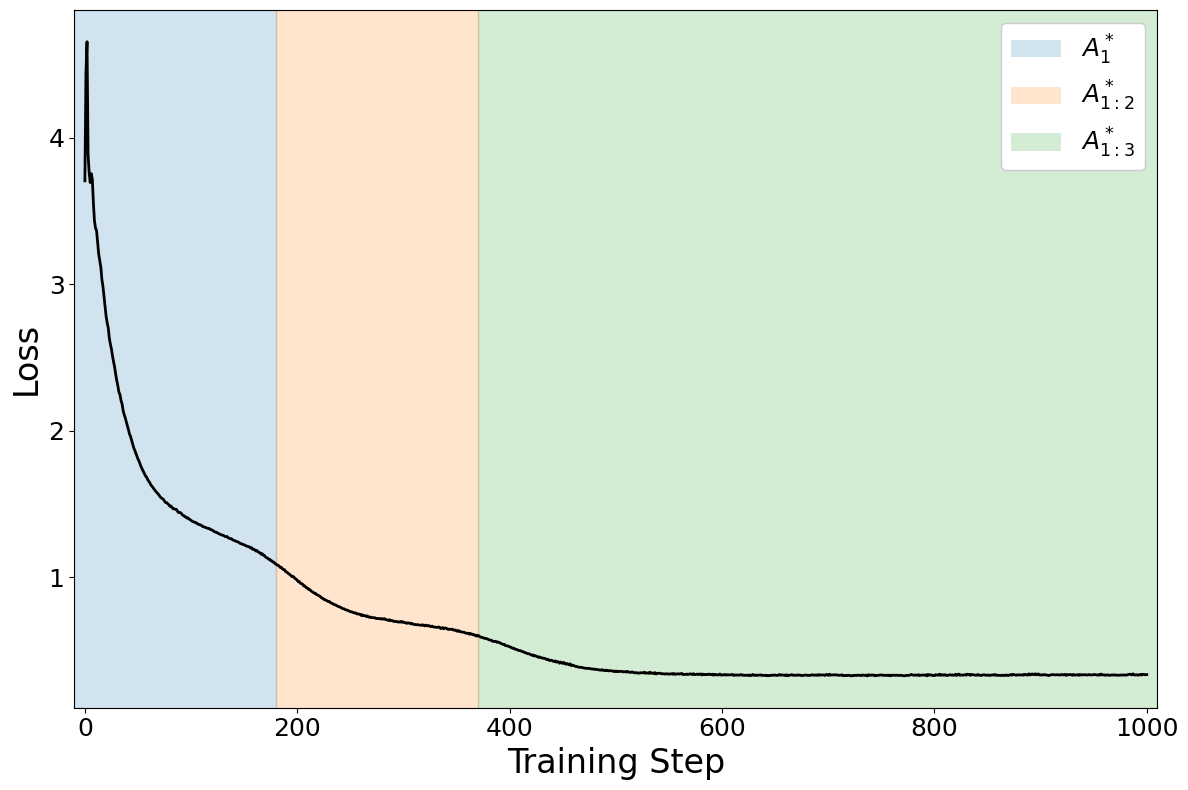

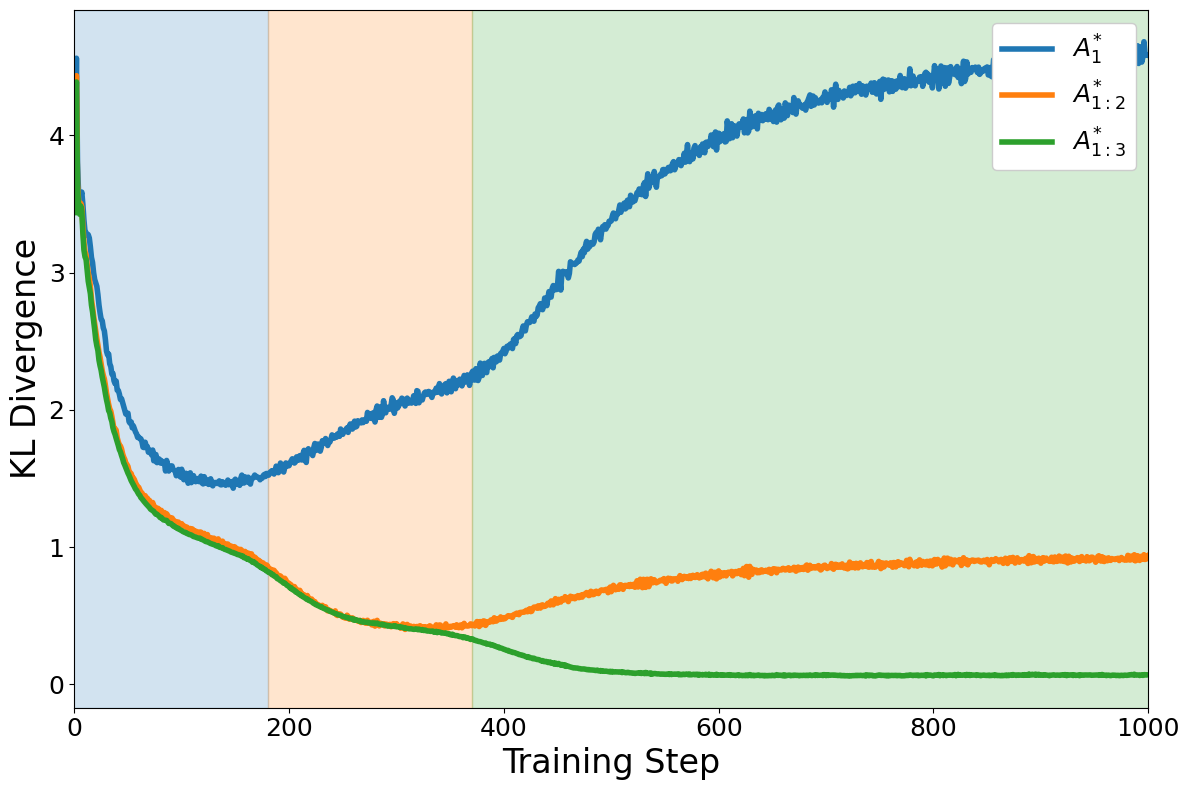

In [3]:
conf = fetch_run_data(TWO_LAYER_MINIMAL, metrics=["val_loss"])["config"]
assert conf["student"]["num_blocks"] == 2
assert conf["student"]["use_mlp"] is False

plot_val_loss_simple(
    run_id=TWO_LAYER_MINIMAL,
    divergence_steps=[2180, 2370],
    shift_steps=2000,
    max_steps=3000,
    save_name=output_path("val-loss-2layer-minimal"),
)

plot_kl_divergence_simple(
    run_id=TWO_LAYER_MINIMAL,
    learnable=False,
    divergence_steps=[2180, 2370],
    shift_steps=2000,
    max_steps=3000,
    save_name=output_path("kl-2layer-minimal"),
)


## Figure 12: Two-Layer Full Transformer

The full two-layer transformer shows the same qualitative progression, though the first stage is less visually pronounced in the report.


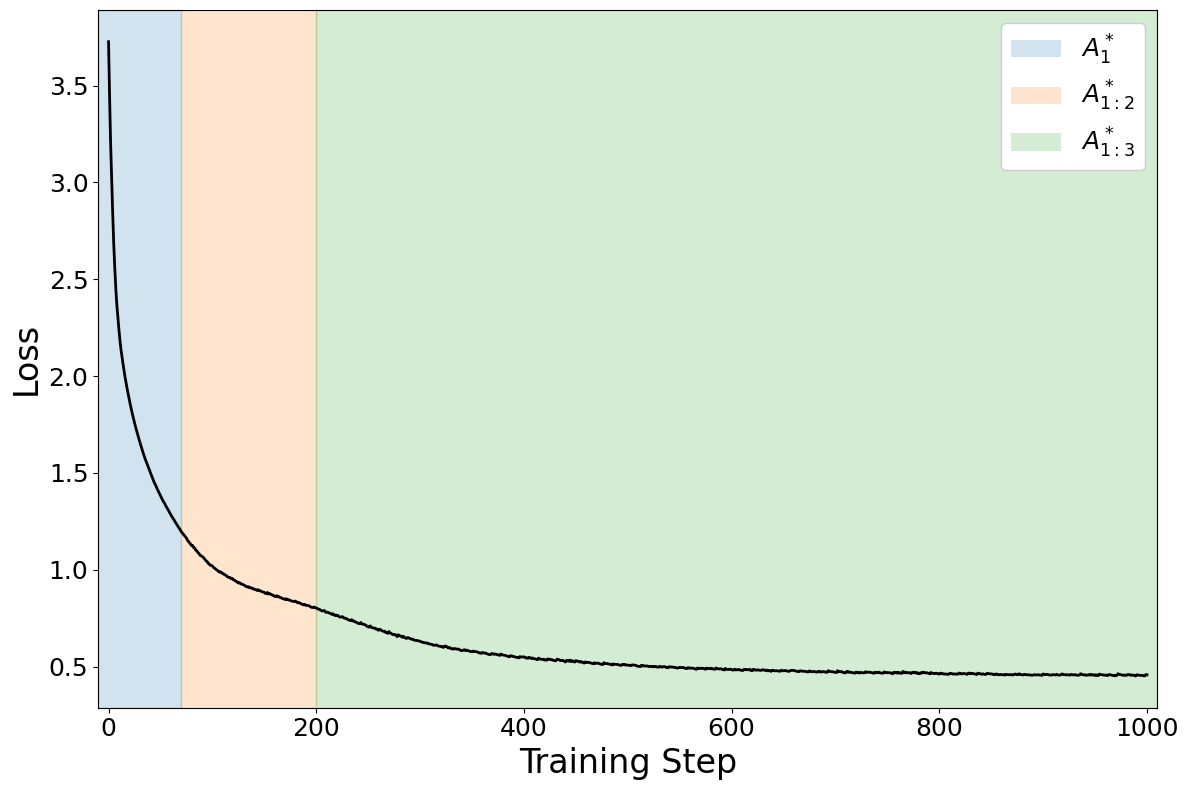

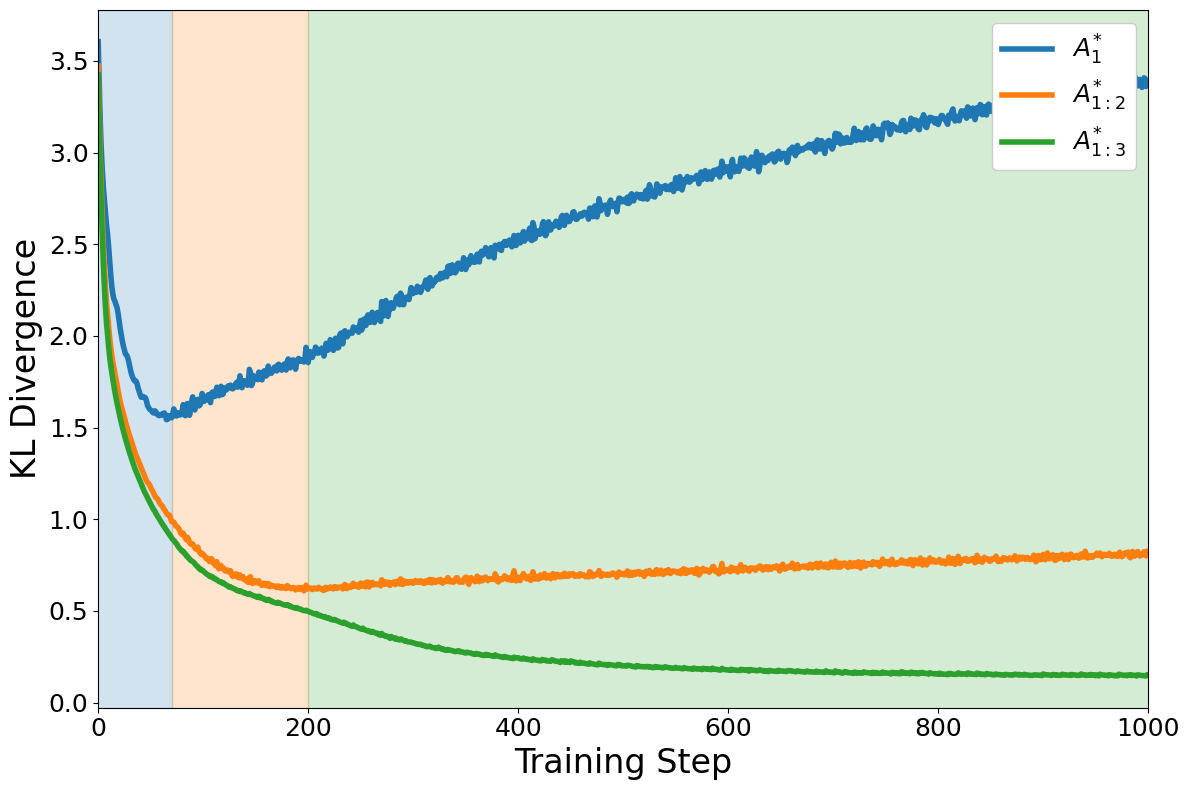

In [4]:
conf = fetch_run_data(TWO_LAYER_FULL, metrics=["val_loss"])["config"]
assert conf["student"]["num_blocks"] == 2
assert conf["student"]["use_mlp"] is True

plot_val_loss_simple(
    run_id=TWO_LAYER_FULL,
    divergence_steps=[2070, 2200],
    shift_steps=2000,
    max_steps=3000,
    save_name=output_path("val-loss-2layer-full"),
)

plot_kl_divergence_simple(
    run_id=TWO_LAYER_FULL,
    learnable=False,
    divergence_steps=[2070, 2200],
    shift_steps=2000,
    max_steps=3000,
    save_name=output_path("kl-2layer-full"),
)
